# Pré-processamento de Dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import *

## Visualização geral dos dados

In [3]:
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/klike_challenge_dataset.csv")

display(df.head())
print(df.shape)
display(df.info())
display(df.describe(include="all"))
print("\nValores nulos por coluna:")
print(df.isnull().sum().sort_values(ascending=False))
display("\nDuplicados:", df.duplicated().sum())

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
0,KLK-0001,2024-01-01,Meta,Branding,awareness,18-24,False,NaN,vertical,True,True,False,True,medium,0.39,150825,5882,0.0390,0.82,4823.24,48,0.00,0.00,3.9,0.0446,63.6
1,KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,NaN,horizontal,True,True,True,True,low,0.07,7433,493,0.0664,3.54,1745.22,34,NaN,0.16,6.4,0.0217,70.0
2,KLK-0003,2024-05-04,TikTok,SaaS,traffic,25-34,False,8.0,vertical,True,True,True,True,medium,0.43,193198,15069,0.0780,0.38,5726.22,492,51053.44,8.92,8.0,0.1000,99.1
3,KLK-0004,2024-12-27,TikTok,Lead Gen,engagement,25-34,False,27.0,quadrado,False,True,True,True,medium,0.54,6506,601,0.0925,0.71,426.71,19,1113.78,2.61,20.3,0.0414,74.9
4,KLK-0005,2024-07-10,Meta,Branding,engagement,25-34,False,34.0,vertical,True,True,True,True,low,0.35,63830,2355,0.0369,0.38,894.90,13,0.00,0.00,34.0,0.0184,77.9


(500, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_id          500 non-null    object 
 1   date                 500 non-null    object 
 2   platform             500 non-null    object 
 3   category             500 non-null    object 
 4   objective            500 non-null    object 
 5   target_audience_age  500 non-null    object 
 6   is_retargeting       500 non-null    bool   
 7   video_duration_s     461 non-null    float64
 8   format               500 non-null    object 
 9   has_subtitle         454 non-null    object 
 10  has_cta              500 non-null    bool   
 11  has_hook             500 non-null    bool   
 12  has_face             500 non-null    bool   
 13  text_density         500 non-null    object 
 14  music_voice_ratio    462 non-null    float64
 15  impressions          500 non-n

None

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
count,500,500,500,500,500,500,500,461.000000,500,454,500,500,500,500,462.000000,5.000000e+02,500.000000,500.000000,472.000000,500.000000,500.0000,475.000000,500.000000,473.000000,468.000000,500.0000
unique,500,273,3,5,5,4,2,NaN,3,2,2,2,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,KLK-0001,2024-05-10,Meta,E-commerce,conversions,25-34,False,NaN,vertical,True,True,True,True,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,6,241,165,165,143,383,NaN,269,263,347,256,269,230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.392625,NaN,NaN,NaN,NaN,NaN,NaN,0.399848,1.537385e+05,3594.104000,0.070968,1.112903,4213.151620,131.3520,6367.936863,2.499000,10.664271,0.027952,60.1568
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.529351,NaN,NaN,NaN,NaN,NaN,NaN,0.202674,1.171736e+06,7018.212512,0.045302,1.955625,11573.975576,314.5654,19267.180696,3.592365,10.533275,0.023057,15.5891
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.020000,1.000000e+03,4.000000,0.002200,0.050000,2.960000,0.0000,0.000000,0.000000,0.400000,0.001000,10.4000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.230000,9.986000e+03,461.750000,0.033200,0.530000,313.452500,10.0000,262.175000,0.430000,4.700000,0.011100,49.7750
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.385000,2.324100e+04,1351.000000,0.062750,0.710000,1031.000000,34.5000,1201.050000,1.490000,7.700000,0.021400,60.5500
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.550000,5.517275e+04,3583.250000,0.104800,1.020000,2867.952500,111.0000,4189.025000,3.250000,13.900000,0.038800,71.9250



Valores nulos por coluna:
has_subtitle           46
video_duration_s       39
music_voice_ratio      38
engagement_rate        32
cpc                    28
avg_watch_time_s       27
revenue                25
campaign_id             0
roas                    0
conversions             0
spend                   0
ctr                     0
clicks                  0
impressions             0
text_density            0
date                    0
has_face                0
has_hook                0
has_cta                 0
format                  0
is_retargeting          0
target_audience_age     0
objective               0
category                0
platform                0
klike_score             0
dtype: int64


'\nDuplicados:'

0

### Impressões:
- É possível observar que há algumas colunas com valores nulos como `has_subtitle`, `video_duration_s`, `music_voice_ratio`, `engagement_rate`, `cpc`, `avg_watch_time_s` e `revenue`

- Precisamos analisar caso a caso o que será feito com cada uma dessas colunas

## Tratando nulos

Investigaremos primeiro revenue analisando todos os registros em que `revenue` é nulo

In [4]:
df.loc[df.revenue.isnull(),:]

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
1,KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,NaN,horizontal,True,True,True,True,low,0.07,7433,493,0.0664,3.54,1745.22,34,NaN,0.16,6.4,0.0217,70.0
30,KLK-0031,2024-12-04,TikTok,Lead Gen,conversions,35-44,False,16.0,vertical,True,True,True,False,medium,NaN,78620,6690,0.0851,0.58,3880.20,268,NaN,3.25,9.0,0.0252,78.4
58,KLK-0059,2024-01-02,Meta,Branding,awareness,45+,True,22.0,vertical,False,True,False,False,low,0.63,11848,228,0.0193,1.04,237.12,3,NaN,0.00,18.4,0.0517,23.7
109,KLK-0110,2024-06-08,Meta,Branding,engagement,45+,False,8.0,horizontal,True,True,True,False,low,0.49,62501,1781,0.0285,0.83,1478.23,5,NaN,0.00,5.2,0.0067,60.0
144,KLK-0145,2024-09-02,Meta,E-commerce,conversions,35-44,False,11.0,horizontal,False,True,True,False,low,0.14,3352,401,0.1198,0.63,252.63,6,NaN,1.48,NaN,0.0156,58.5
158,KLK-0159,2024-07-29,Meta,App Install,traffic,18-24,False,NaN,quadrado,True,True,True,False,medium,0.52,25389,2409,0.0949,0.63,1517.67,216,NaN,1.24,5.0,0.0323,80.4
182,KLK-0183,2024-08-16,LinkedIn,E-commerce,traffic,25-34,False,42.0,horizontal,True,True,False,False,low,0.40,4445,139,0.0314,2.22,308.58,4,NaN,0.47,19.4,0.0175,33.8
187,KLK-0188,2024-06-12,TikTok,E-commerce,traffic,18-24,False,14.0,vertical,False,False,True,True,low,0.69,72341,10279,0.1421,0.41,4214.39,355,NaN,4.31,5.5,0.0905,61.0
193,KLK-0194,2024-06-20,TikTok,E-commerce,traffic,18-24,False,13.0,vertical,NaN,True,False,True,low,0.14,7232,309,0.0428,0.60,185.40,15,NaN,2.19,2.5,0.0466,58.6
202,KLK-0203,2024-10-29,Meta,SaaS,awareness,35-44,False,18.0,vertical,False,True,False,False,high,0.17,10655,334,0.0314,0.76,253.84,6,NaN,3.16,8.6,0.0164,42.6


É possível observar que para todos os casos que `revenue` é nulo possuímos os valores de `roas` e `spend` preenchidos, podemos preenchê-la a partir do cálculo com essas outras duas variáveis já que `revenue` = `roas` * `spend`

Agora investigaremos os registros de `cpc` nulos.

In [5]:
df.loc[df.cpc.isnull(), :]

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
6,KLK-0007,2024-05-02,Meta,Lead Gen,engagement,18-24,False,NaN,quadrado,True,False,False,True,medium,0.33,12960,1877,0.1449,NaN,2158.55,37,2233.56,1.03,11.9,0.0530,64.9
75,KLK-0076,2024-03-06,TikTok,Lead Gen,conversions,45+,False,6.0,vertical,True,True,False,False,low,0.50,15053,505,0.0336,NaN,171.70,17,1201.05,7.00,1.9,0.0365,59.5
78,KLK-0079,2024-03-17,Meta,SaaS,traffic,35-44,True,12.0,quadrado,False,True,False,False,low,0.44,82155,8330,0.1014,NaN,2915.50,332,36690.69,12.58,2.2,0.0253,50.2
110,KLK-0111,2024-10-13,Meta,E-commerce,conversions,25-34,False,23.0,vertical,True,True,True,False,low,0.21,26827,3608,0.1345,NaN,3319.36,204,12733.14,3.84,13.9,0.0431,73.9
118,KLK-0119,2024-01-08,LinkedIn,Lead Gen,engagement,45+,False,35.0,horizontal,False,True,False,True,low,0.55,2489,331,0.1333,NaN,1234.63,11,547.83,0.44,21.2,0.0383,55.6
130,KLK-0131,2024-08-21,Meta,Branding,engagement,35-44,False,46.0,horizontal,NaN,True,True,True,low,0.10,4390,171,0.0391,NaN,121.41,1,0.00,0.00,11.6,0.0140,68.6
145,KLK-0146,2024-09-14,Meta,Lead Gen,conversions,35-44,True,22.0,horizontal,True,True,True,True,medium,0.72,15838,2375,0.1500,NaN,1330.00,58,4951.12,3.72,12.8,0.0289,83.0
161,KLK-0162,2024-01-10,TikTok,Lead Gen,engagement,18-24,True,7.0,vertical,False,True,True,False,medium,0.39,12456,534,0.0429,NaN,170.88,50,2824.87,16.53,3.6,0.0297,72.7
185,KLK-0186,2024-12-19,TikTok,App Install,app_install,35-44,False,12.0,vertical,False,True,True,False,medium,0.41,48620,2338,0.0481,NaN,1052.10,158,1322.18,1.26,4.2,0.0150,61.4
199,KLK-0200,2024-04-28,TikTok,SaaS,traffic,25-34,False,30.0,vertical,True,True,False,True,low,0.62,123307,16017,0.1299,NaN,8969.52,347,44111.25,4.92,8.2,0.0835,69.2


Assim como no `revenue` que poderia ser calculado a partir de outras duas colunas, `cpc` também pode ser calculado a partir de `clicks` e `spend`, nesse caso também faremos isso já que as outras duas colunas possuem todos os valores preenchidos.

- Para `video_duration_s` foi decidido preencher com a mediana para evitar a distorção dos dados por outliers.

- Para `has_subtitle` foi decidido criar uma nova categoria "unknown" para evitar um preenchimento que causasse ruído no modelo já não era possível simplemente abrir mão desses registros tendo em vista que representavem quase 10% de uma base de dados já pequena. 

In [5]:
# 1) Preenchimento de revenue com base em roas * spend, apenas onde revenue está nulo
mask_revenue = df["revenue"].isnull() & df["roas"].notnull() & (df["spend"] >= 0)
df.loc[mask_revenue, "revenue"] = df.loc[mask_revenue, "roas"] * df.loc[mask_revenue, "spend"]

# 2) Preenchimento de CPC com base em spend / clicks, apenas onde CPC está nulo
mask_cpc = df["cpc"].isnull() & (df["clicks"] > 0)
df.loc[mask_cpc, "cpc"] = df.loc[mask_cpc, "spend"] / df.loc[mask_cpc, "clicks"]

# 3) Preenchimento de video_duration_s com a mediana
median_duration = df["video_duration_s"].median()
df["video_duration_s"] = df["video_duration_s"].fillna(median_duration)

# 4) has_subtitle: transformar em categoria com valor "unknown" para ausentes
df["has_subtitle"] = df["has_subtitle"].astype("object")
df["has_subtitle"] = df["has_subtitle"].fillna("unknown")

Investigando `music_voice_ratio`

In [6]:
display(df["music_voice_ratio"].describe())
df["music_voice_ratio"].isnull().mean()

count    462.000000
mean       0.399848
std        0.202674
min        0.020000
25%        0.230000
50%        0.385000
75%        0.550000
max        0.920000
Name: music_voice_ratio, dtype: float64

0.076

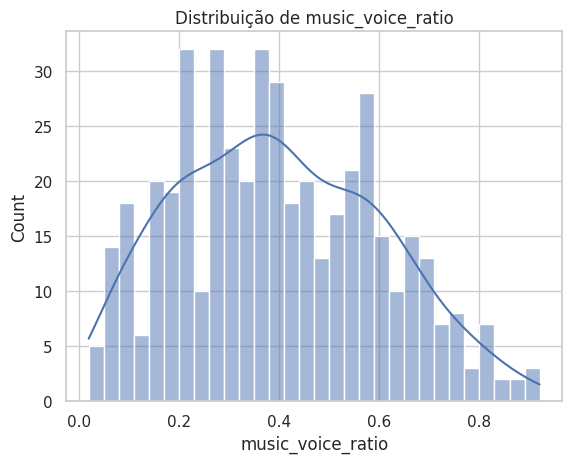

In [7]:
sns.histplot(df["music_voice_ratio"], bins=30, kde=True)
plt.title("Distribuição de music_voice_ratio")
plt.show()

In [8]:
print("Média score (não nulo):", df[df["music_voice_ratio"].notnull()]["klike_score"].mean())
print("Média score (nulo):", df[df["music_voice_ratio"].isnull()]["klike_score"].mean())

Média score (não nulo): 60.05238095238094
Média score (nulo): 61.42631578947369


In [9]:
# Imputação de music_voice_ratio com a mediana
median_ratio = df["music_voice_ratio"].median()
df["music_voice_ratio"] = df["music_voice_ratio"].fillna(median_ratio)

`music_voice_ratio` apresenta uma distribuição contínua com valores concentrados entre 0.2 e 0.6, os registros nulos representam aproximadamente 7.6% de toda a base e a comparação entre campanhas com e sem valores mostrou uma diferença irrelevante no klike_score médio, portanto foi decidido preencher com a mediana da distribuição.

Por fim, analisando `engagement_rate` e `avg_watch_time_s`: 

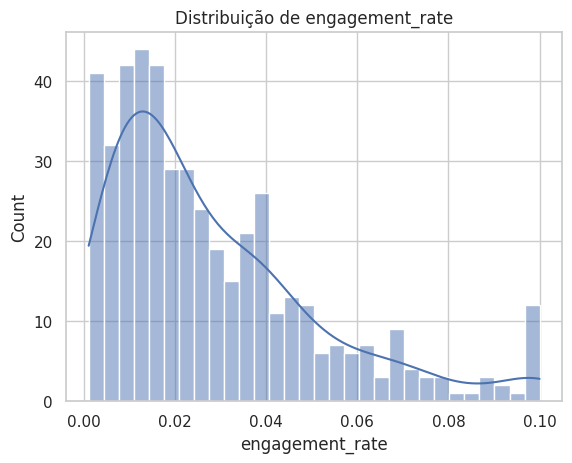

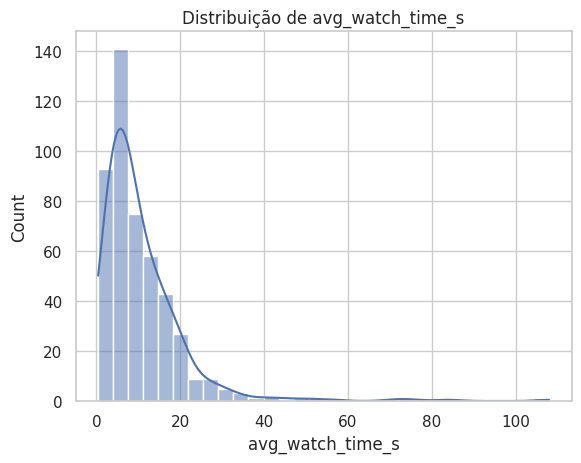

In [10]:
cols = ["engagement_rate", "avg_watch_time_s"]

for col in cols:
    plt.figure()
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribuição de {col}")
    plt.show()

In [11]:
for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].isnull().mean())
    
    print("\nMédia quando NÃO é nulo:")
    print(df[df[col].notnull()]["klike_score"].mean())
    
    print("\nMédia quando É nulo:")
    print(df[df[col].isnull()]["klike_score"].mean())


--- engagement_rate ---
0.064

Média quando NÃO é nulo:
59.94850427350428

Média quando É nulo:
63.203125

--- avg_watch_time_s ---
0.054

Média quando NÃO é nulo:
60.12896405919662

Média quando É nulo:
60.644444444444446


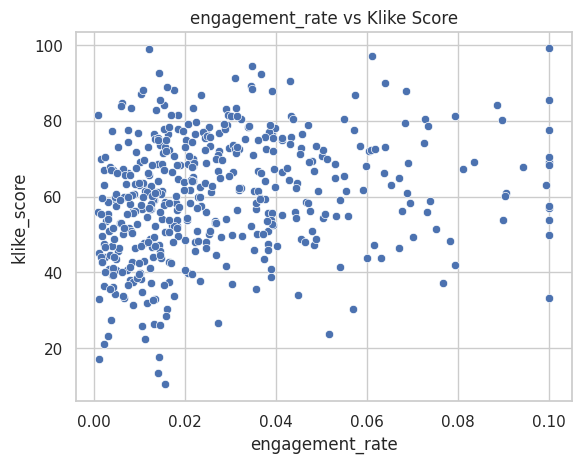

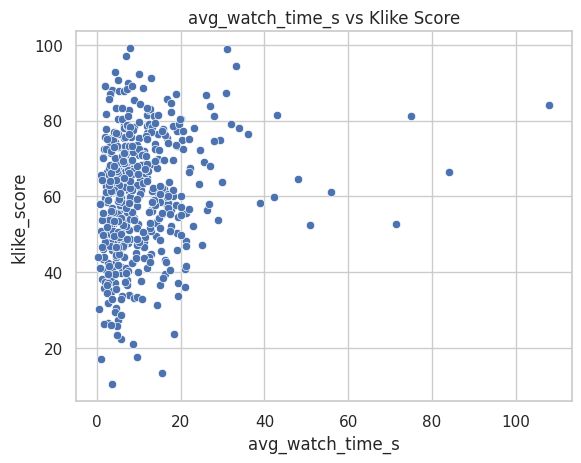

In [12]:
for col in cols:
    plt.figure()
    sns.scatterplot(data=df, x=col, y="klike_score")
    plt.title(f"{col} vs Klike Score")
    plt.show()

Ambas as variáveis apresentaram distribuições assimétricas à direita, observou-se uma leve relação positiva entre `engagement_rate` e klike_score, no entanto os valores ausentes não carregam informação relevante ao ponto de diferenciar o score médio. Portanto, foi decidido preencher os valores faltantes com a mediana.

In [13]:
# engagement_rate
median_engagement = df["engagement_rate"].median()
df["engagement_rate"] = df["engagement_rate"].fillna(median_engagement)

# avg_watch_time_s
median_watch = df["avg_watch_time_s"].median()
df["avg_watch_time_s"] = df["avg_watch_time_s"].fillna(median_watch)

## Analisando a presença de outliers 

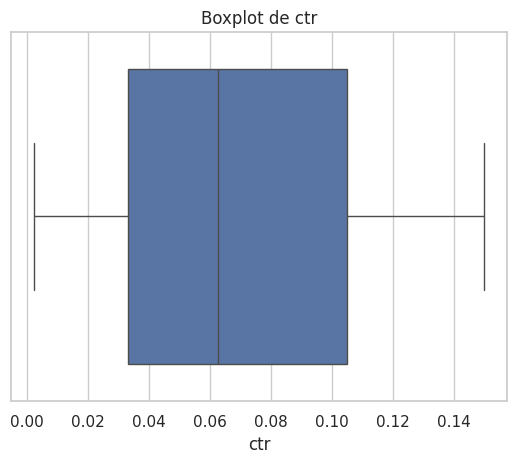

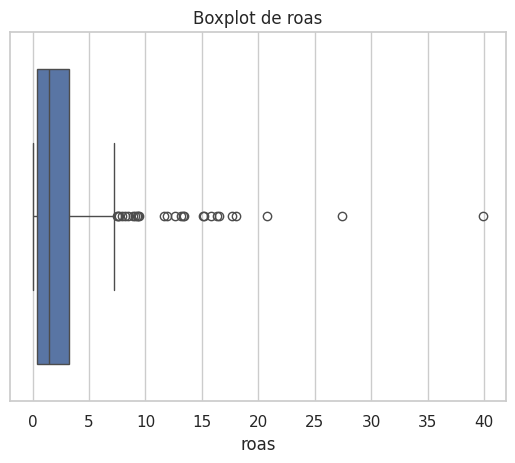

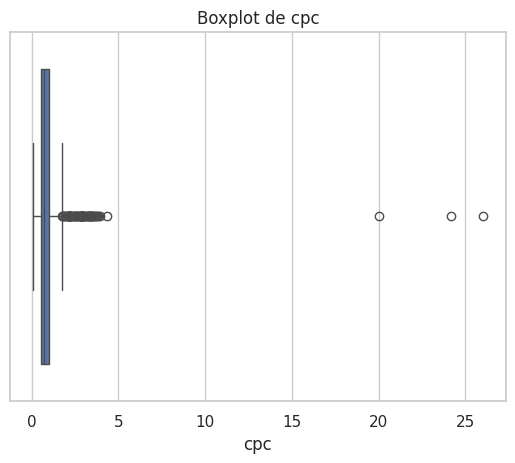

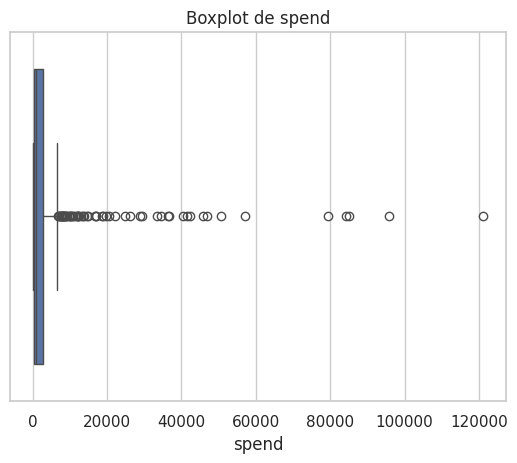

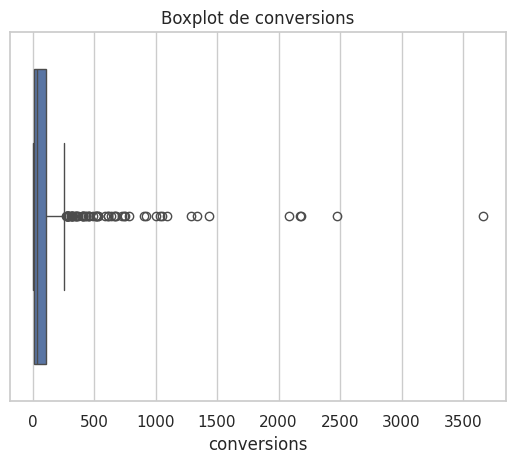

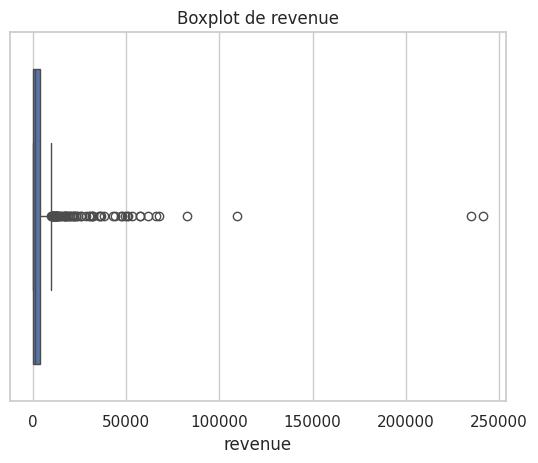

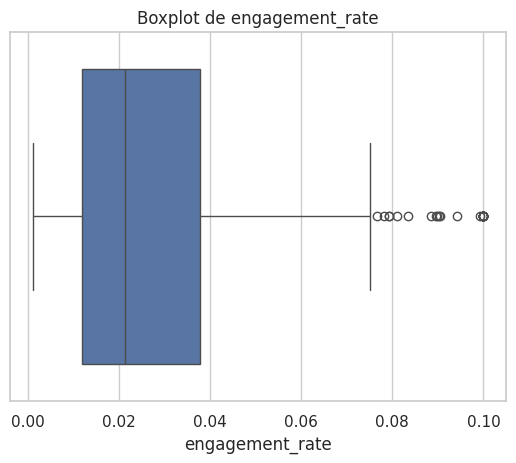

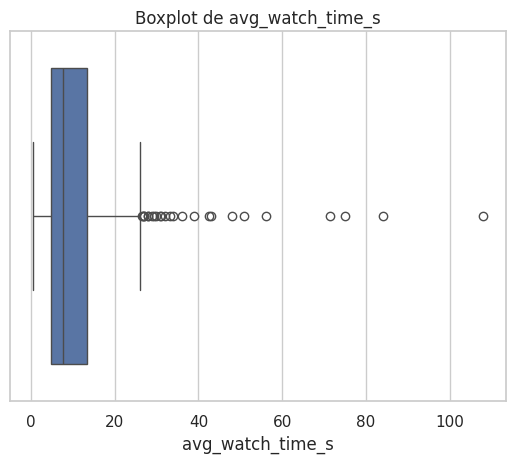

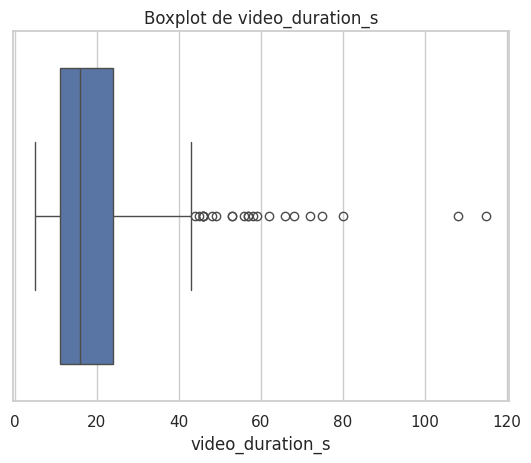

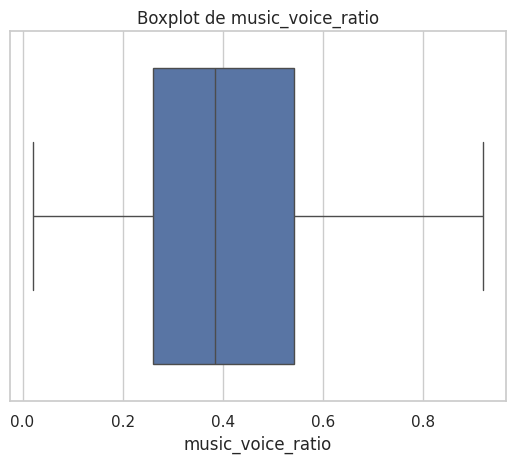

In [14]:
num_cols = [
    "ctr", "roas", "cpc", "spend", "conversions",
    "revenue", "engagement_rate", "avg_watch_time_s",
    "video_duration_s", "music_voice_ratio"
]

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

Outliers foram identificados nessa etapa, no entanto, para todos os casos correspondem a métricas de resultados que não serão utilizadas para alimentar o modelo. Então, por hora não vamos fazer um tratamento em relação a esses casos. 